 ### Build a basic chatbot with Langgraph

In [15]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

In [16]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [17]:
from dotenv import load_dotenv
load_dotenv(override=True)
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
llm.invoke('What model are you? gpt?')

AIMessage(content="Yes, I am based on OpenAI's GPT (Generative Pre-trained Transformer) architecture. Specifically, I have been developed from iterations of this model. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 15, 'total_tokens': 53, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cca4f51b32', 'finish_reason': 'stop', 'logprobs': None}, id='run--019e4abf-d5a2-70d3-94ed-9cec77f96e3c-0', usage_metadata={'input_tokens': 15, 'output_tokens': 38, 'total_tokens': 53, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [18]:
def chatbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

In [19]:
graph_builder = StateGraph(State)

graph_builder.add_node('chatbot', chatbot)

graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('chatbot', END)

graph = graph_builder.compile()

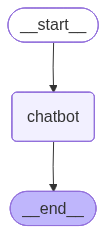

In [20]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
responses = graph.invoke({'messages':'What is RAG?'})

In [23]:
responses['messages'][-1]

AIMessage(content='RAG stands for "Retrieval-Augmented Generation," a technique in natural language processing (NLP) that combines retrieval of relevant documents with generative models to produce more accurate and informed responses. This approach typically involves two main components:\n\n1. **Retrieval Module**: This component searches a large corpus of documents to find relevant information based on a given query or context. It functions similarly to a search engine and is often implemented using models like BM25 or dense retrieval models like DPR (Dense Passage Retrieval).\n\n2. **Generative Module**: Once relevant documents are retrieved, a generative model, often based on architectures like GPT (Generative Pre-trained Transformer) or BART (Bidirectional and Auto-Regressive Transformers), is used to generate a coherent and contextually enriched response. The generative model leverages the retrieved documents to produce more informed and contextually relevant outputs.\n\nThe RAG a

### LLM with tools

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv
load_dotenv(override=True)

llm = ChatOpenAI(model='gpt-4o')

c:\Users\visha\agentic-AI\youtube_projects\AgenticLanggraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


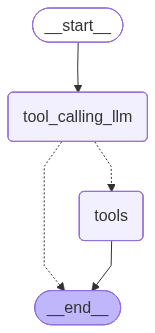

In [2]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

#-------------Tool 1-------------------#
from langchain_tavily import TavilySearch
tavily_tool = TavilySearch(max_results=1)
# tavily_tool.invoke('Messi')

#-------------Tool 2-------------------#
def add(a,b):
    '''
    This function adds two integers

    Args
    a : int
    b: int

    returns: int (adds a, b)

    '''
    return a+b

#-------Combine tools-----------#
tools = [tavily_tool, add]
llm_with_tools = llm.bind_tools(tools)


def tool_calling_llm(state:State):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(State)

#Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

#Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

#Compile
graph = builder.compile()

#Visualize
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [10]:
response = graph.invoke({'messages': 'Tell me the current whether in kanyakumari'})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me the current whether in kanyakumari
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_xsHozFPHuxoqCgalCcCpLoXb)
 Call ID: call_xsHozFPHuxoqCgalCcCpLoXb
  Args:
    query: current weather in Kanyakumari
================================= Tool Message =================================
Name: tavily_search

{"query": "current weather in Kanyakumari", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Kanyakumari", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'Kanyakumari', 'region': 'Tamil Nadu', 'country': 'India', 'lat': 8.0761, 'lon': 77.5483, 'tz_id': 'Asia/Kolkata', 'localtime_epoch': 1779426724, 'localtime': '2026-05-22 10:42'}, 'current': {'last_updated_epoch': 1779426000, 'last_updated': '2026-05-22 10:30', 'temp_c': 30.9, 'temp_f': 87.5, 'is_day': 1, 'condition':

In [11]:
response = graph.invoke({'messages': 'What is 2 added by 3'})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 added by 3
================================== Ai Message ==================================
Tool Calls:
  add (call_JVHMEtZRcDBfLVQaoJ3U9YvM)
 Call ID: call_JVHMEtZRcDBfLVQaoJ3U9YvM
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5


In [12]:
response = graph.invoke({'messages': 'What is RAG'})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is RAG
================================== Ai Message ==================================

RAG stands for Retrieval-Augmented Generation. It is a technique often used in natural language processing (NLP) and artificial intelligence (AI) for enhancing the capabilities of models. Here's a breakdown of the concept:

1. **Retrieval**: In this step, the model retrieves relevant information or data from a large corpus of documents or datasets. This is often done by using search engines or specific retrieval models that can select pertinent information based on the current query or context.

2. **Augmentation**: After retrieval, the relevant information is used to augment the input data. This means the model now has more context or details to work with, beyond the original input.

3. **Generation**: Finally, the augmented input is fed into a generation model (usually a language model), which uses this enriche

### REACT AGENT

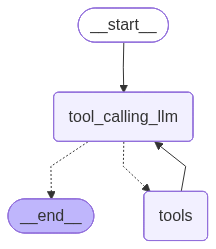

================================ Human Message =================================

Give me recent news about AI and then add 3 + 5 and then add by 6
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_T3wUAxyhzW5dNJ5mJd0q7dLL)
 Call ID: call_T3wUAxyhzW5dNJ5mJd0q7dLL
  Args:
    query: recent AI news
    time_range: week
    topic: news
  add (call_cTUBjBmEQc2SIGcfzXno41mA)
 Call ID: call_cTUBjBmEQc2SIGcfzXno41mA
  Args:
    a: 3
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/15/ai-tech-brief-ai-integrators-hit-hill/", "title": "AI & Tech Brief: AI “integrators” hit the Hill - The Washington Post", "score": 0.95430803, "published_date": "Fri, 15 May 2026 19:00:18 GMT", "content": "AI & Tec

In [22]:
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv
load_dotenv(override=True)

llm = ChatOpenAI(model='gpt-4o')

class State(TypedDict):
    messages : Annotated[list, add_messages]

#-------------Tool 1-------------------#
from langchain_tavily import TavilySearch
tavily_tool = TavilySearch(max_results=1)
# tavily_tool.invoke('Messi')

#-------------Tool 2-------------------#
def add(a,b):
    '''
    This function adds two integers

    Args
    a : int
    b: int

    returns: int (adds a, b)

    '''
    return a+b

#-------Combine tools-----------#
tools = [tavily_tool, add]
llm_with_tools = llm.bind_tools(tools)


def tool_calling_llm(state:State):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(State)

#Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

#Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

#Compile
graph = builder.compile()

#Visualize
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


response = graph.invoke({'messages': 'Give me recent news about AI and then add 3 + 5 and then add by 6'})
for m in response['messages']:
    m.pretty_print()

### Adding memory in Langgraph

c:\Users\visha\agentic-AI\youtube_projects\AgenticLanggraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


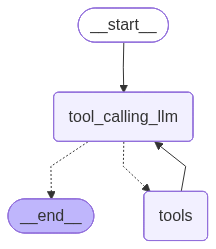

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

from dotenv import load_dotenv
load_dotenv(override=True)

llm = ChatOpenAI(model='gpt-4o')

class State(TypedDict):
    messages : Annotated[list, add_messages]

#-------------Tool 1-------------------#
from langchain_tavily import TavilySearch
tavily_tool = TavilySearch(max_results=1)
# tavily_tool.invoke('Messi')

#-------------Tool 2-------------------#
def add(a,b):
    '''
    This function adds two integers

    Args
    a : int
    b: int

    returns: int (adds a, b)

    '''
    return a+b

#-------Combine tools-----------#
tools = [tavily_tool, add]
llm_with_tools = llm.bind_tools(tools)


def tool_calling_llm(state:State):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(State)

#Node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

#Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

#Compile
graph = builder.compile(checkpointer=memory)

#Visualize
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
config = {'configurable':{'thread_id':"1"}}

response = graph.invoke({'messages':'Hi, Im AJai'}, config=config)
print(response['messages'][-1].content)

Hello, AJai! How can I assist you today?


In [3]:
response = graph.invoke({'messages':'Whats my name?'}, config=config)
print(response['messages'][-1].content)

Your name is AJai.


### Streaming

In [4]:
config = {'configurable':{'thread_id':"2"}}

for chunk in graph.stream({'messages':'I like football'}, config=config, stream_mode='updates'):
    print(chunk)

{'tool_calling_llm': {'messages': [AIMessage(content="That's great! Football is an exciting sport enjoyed by millions around the world. Do you have a favorite team or player, or is there something specific you'd like to know or discuss about football?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 1232, 'total_tokens': 1271, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5dcbd0db7f', 'finish_reason': 'stop', 'logprobs': None}, id='run--019e5840-770a-7983-b3ce-fb1bc15b553f-0', usage_metadata={'input_tokens': 1232, 'output_tokens': 39, 'total_tokens': 1271, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [5]:
config = {'configurable':{'thread_id':"2"}}

for chunk in graph.stream({'messages':'I like cricket too'}, config=config, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='I like football', additional_kwargs={}, response_metadata={}, id='3b0e2916-6f5e-40db-83ab-7336a5853e89'), AIMessage(content="That's great! Football is an exciting sport enjoyed by millions around the world. Do you have a favorite team or player, or is there something specific you'd like to know or discuss about football?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 1232, 'total_tokens': 1271, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5dcbd0db7f', 'finish_reason': 'stop', 'logprobs': None}, id='run--019e5840-770a-7983-b3ce-fb1bc15b553f-0', usage_metadata={'input_tokens': 1232, 'output_tokens': 39, 'total_tokens': 1271, 'input_token_details': {'audio': 0, 'ca

In [7]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph.astream_events({"messages":["Hi My name is AJai and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is AJai and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e5840-bad7-7f62-bf27-8598294faad1', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is AJai and I like to play cricket', additional_kwargs={}, response_metadata={}, id='aac3dd6c-db41-4cf3-81c1-153857193717')]}}, 'name': 'tool_calling_llm', 'tags': ['graph:step:1'], 'run_id': '019e5840-badc-75c3-9261-d4218c972a1d', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'tool_calling_llm', 'langgraph_triggers': ('branch:to:tool_calling_llm',), 'langgraph_path': ('__pregel_pull', 'tool_calling_llm'), 'langgraph_checkpoint_ns': 'tool_calling_llm:2b034c8f-e9af-67eb-f9dd-a49b275c54da'}, 'parent_ids': ['019e5840-bad7-7f62-bf27-8598294faad1']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content=